In [1]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return 1 / (1 + x**2)

x_data = np.arange(-4, 4.01, 0.5)

y_data = f(x_data)

print("x values:")
print(x_data)

print("\ny values:")
print(y_data)

x values:
[-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2.   2.5
  3.   3.5  4. ]

y values:
[0.05882353 0.0754717  0.1        0.13793103 0.2        0.30769231
 0.5        0.8        1.         0.8        0.5        0.30769231
 0.2        0.13793103 0.1        0.0754717  0.05882353]


In [3]:
def divided_difference_table(x, y):

    n = len(x)

    table = np.zeros((n, n))

    table[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):

            table[i, j] = (
                table[i + 1, j - 1]
                - table[i, j - 1]
            ) / (x[i + j] - x[i])

    return table


def newton_coefficients(table):

    return table[0, :]


def newton_interpolation(x_data, coefficients, x):

    n = len(coefficients)

    result = coefficients[n - 1]

    for i in range(n - 2, -1, -1):

        result = coefficients[i] + (
            x - x_data[i]
        ) * result

    return result

In [4]:
def lagrange_interpolation(x_data, y_data, x):

    n = len(x_data)

    result = 0.0

    for i in range(n):

        term = y_data[i]

        for j in range(n):

            if i != j:

                term *= (
                    (x - x_data[j])
                    / (x_data[i] - x_data[j])
                )

        result += term

    return result

In [6]:
x_eval = np.linspace(-4, 4, 200)

In [7]:
table = divided_difference_table(
    x_data,
    y_data
)

coefficients = newton_coefficients(table)


newton_values = np.array([
    newton_interpolation(
        x_data,
        coefficients,
        x
    )
    for x in x_eval
])


lagrange_values = np.array([
    lagrange_interpolation(
        x_data,
        y_data,
        x
    )
    for x in x_eval
])


# Exact values
exact_values = f(x_eval)

In [8]:
newton_error = np.abs(
    exact_values - newton_values
)

lagrange_error = np.abs(
    exact_values - lagrange_values
)

In [9]:
max_newton_error = np.max(newton_error)

max_lagrange_error = np.max(lagrange_error)

print("Maximum Newton Error:")
print(f"{max_newton_error:.10e}")

print("\nMaximum Lagrange Error:")
print(f"{max_lagrange_error:.10e}")

Maximum Newton Error:
5.8871887906e+00

Maximum Lagrange Error:
5.8871887906e+00


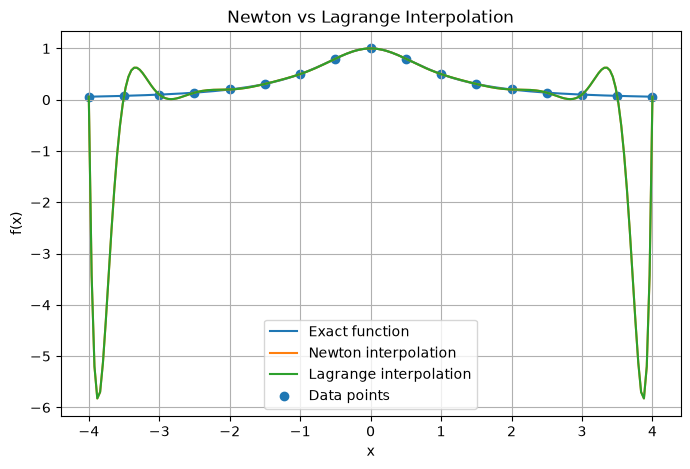

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    exact_values,
    label="Exact function"
)

plt.plot(
    x_eval,
    newton_values,
    label="Newton interpolation"
)

plt.plot(
    x_eval,
    lagrange_values,
    label="Lagrange interpolation"
)

plt.scatter(
    x_data,
    y_data,
    label="Data points"
)

plt.xlabel("x")
plt.ylabel("f(x)")

plt.title(
    "Newton vs Lagrange Interpolation"
)

plt.legend()
plt.grid(True)

plt.show()

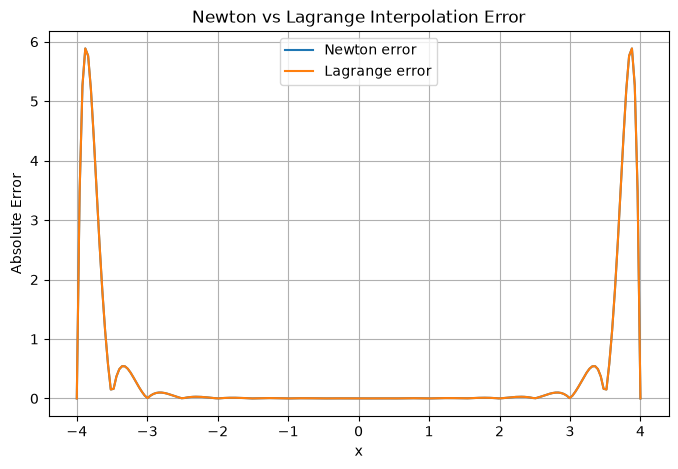

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    newton_error,
    label="Newton error"
)

plt.plot(
    x_eval,
    lagrange_error,
    label="Lagrange error"
)

plt.xlabel("x")

plt.ylabel("Absolute Error")

plt.title(
    "Newton vs Lagrange Interpolation Error"
)

plt.legend()
plt.grid(True)

plt.show()

In [14]:
comparison_points = np.array([
    -3.75,
    -2.25,
    -0.75,
     0.75,
     2.25,
     3.75
])


print("\nComparison at Required Points")
print(
    "x\t\tExact\t\tNewton\t\tLagrange"
)

for point in comparison_points:

    exact = f(point)

    newton = newton_interpolation(
        x_data,
        coefficients,
        point
    )

    lagrange = lagrange_interpolation(
        x_data,
        y_data,
        point
    )

    print(
        f"{point:.2f}\t\t"
        f"{exact:.10f}\t"
        f"{newton:.10f}\t"
        f"{lagrange:.10f}"
    )


Comparison at Required Points
x		Exact		Newton		Lagrange
-3.75		0.0663900415	-4.1253119378	-4.1253119378
-2.25		0.1649484536	0.1919788740	0.1919788740
-0.75		0.6400000000	0.6362738985	0.6362738985
0.75		0.6400000000	0.6362738985	0.6362738985
2.25		0.1649484536	0.1919788740	0.1919788740
3.75		0.0663900415	-4.1253119378	-4.1253119378


Maximum Errors
--------------
Max Newton Error   = 5.8871887906e+00
Max Lagrange Error = 5.8871887906e+00

Comparison at Required Points
x		Exact		Newton		Lagrange
-3.75		0.0663900415	-4.1253119378	-4.1253119378
-2.25		0.1649484536	0.1919788740	0.1919788740
-0.75		0.6400000000	0.6362738985	0.6362738985
0.75		0.6400000000	0.6362738985	0.6362738985
2.25		0.1649484536	0.1919788740	0.1919788740
3.75		0.0663900415	-4.1253119378	-4.1253119378


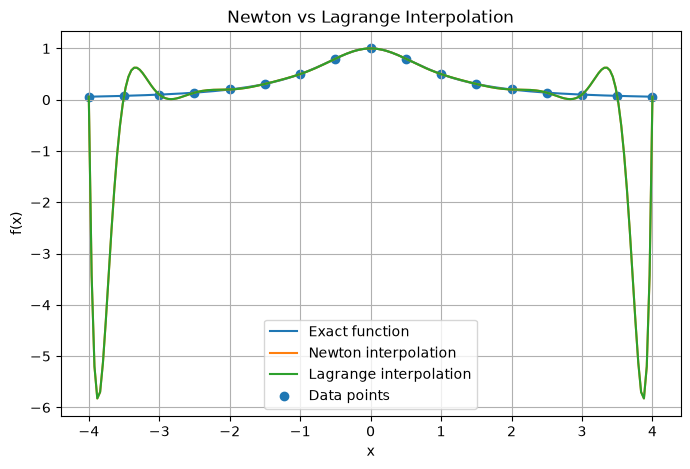

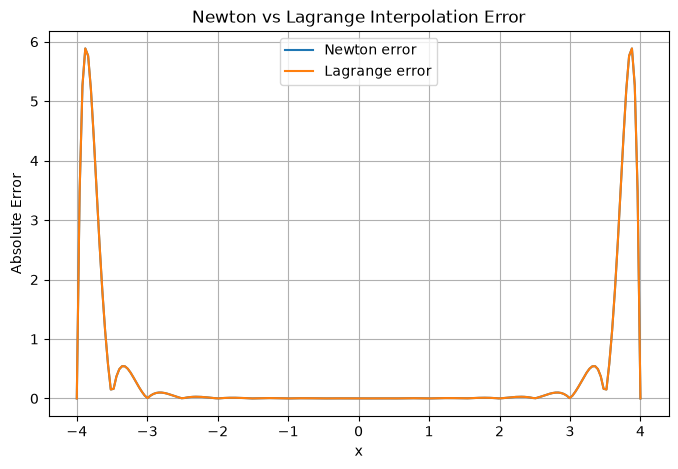

In [15]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Function
# =========================================================

def f(x):
    return 1 / (1 + x**2)


# =========================================================
# Newton interpolation
# =========================================================

def divided_difference_table(x, y):

    n = len(x)

    table = np.zeros((n, n))

    table[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):

            table[i, j] = (
                table[i + 1, j - 1]
                - table[i, j - 1]
            ) / (x[i + j] - x[i])

    return table


def newton_coefficients(table):

    return table[0, :]


def newton_interpolation(x_data, coefficients, x):

    n = len(coefficients)

    result = coefficients[n - 1]

    for i in range(n - 2, -1, -1):

        result = coefficients[i] + (
            x - x_data[i]
        ) * result

    return result


# =========================================================
# Lagrange interpolation
# =========================================================

def lagrange_interpolation(x_data, y_data, x):

    n = len(x_data)

    result = 0.0

    for i in range(n):

        term = y_data[i]

        for j in range(n):

            if i != j:

                term *= (
                    (x - x_data[j])
                    / (x_data[i] - x_data[j])
                )

        result += term

    return result


# =========================================================
# Q4 Data
# =========================================================

x_data = np.arange(-4, 4.01, 0.5)

y_data = f(x_data)


# =========================================================
# Newton coefficients
# =========================================================

table = divided_difference_table(
    x_data,
    y_data
)

coefficients = newton_coefficients(table)


# =========================================================
# 200 evaluation points
# =========================================================

x_eval = np.linspace(-4, 4, 200)

exact_values = f(x_eval)


# =========================================================
# Evaluate Newton and Lagrange
# =========================================================

newton_values = np.array([
    newton_interpolation(
        x_data,
        coefficients,
        x
    )
    for x in x_eval
])


lagrange_values = np.array([
    lagrange_interpolation(
        x_data,
        y_data,
        x
    )
    for x in x_eval
])


# =========================================================
# Calculate errors
# =========================================================

newton_error = np.abs(
    exact_values - newton_values
)

lagrange_error = np.abs(
    exact_values - lagrange_values
)


# =========================================================
# Maximum errors
# =========================================================

max_newton_error = np.max(newton_error)

max_lagrange_error = np.max(lagrange_error)


print("Maximum Errors")
print("--------------")

print(
    f"Max Newton Error   = "
    f"{max_newton_error:.10e}"
)

print(
    f"Max Lagrange Error = "
    f"{max_lagrange_error:.10e}"
)


# =========================================================
# Required comparison points
# =========================================================

comparison_points = np.array([
    -3.75,
    -2.25,
    -0.75,
     0.75,
     2.25,
     3.75
])


print("\nComparison at Required Points")
print(
    "x\t\tExact\t\tNewton\t\tLagrange"
)

for point in comparison_points:

    exact = f(point)

    newton = newton_interpolation(
        x_data,
        coefficients,
        point
    )

    lagrange = lagrange_interpolation(
        x_data,
        y_data,
        point
    )

    print(
        f"{point:.2f}\t\t"
        f"{exact:.10f}\t"
        f"{newton:.10f}\t"
        f"{lagrange:.10f}"
    )


# =========================================================
# Plot 1: Function comparison
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    exact_values,
    label="Exact function"
)

plt.plot(
    x_eval,
    newton_values,
    label="Newton interpolation"
)

plt.plot(
    x_eval,
    lagrange_values,
    label="Lagrange interpolation"
)

plt.scatter(
    x_data,
    y_data,
    label="Data points"
)

plt.xlabel("x")
plt.ylabel("f(x)")

plt.title(
    "Newton vs Lagrange Interpolation"
)

plt.legend()
plt.grid(True)

plt.show()


# =========================================================
# Plot 2: Error comparison
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    newton_error,
    label="Newton error"
)

plt.plot(
    x_eval,
    lagrange_error,
    label="Lagrange error"
)

plt.xlabel("x")

plt.ylabel("Absolute Error")

plt.title(
    "Newton vs Lagrange Interpolation Error"
)

plt.legend()
plt.grid(True)

plt.show()